# Notebook 02 — Molecular Visualization: Drawing Molecules for Analysis and Publication

In the wet lab, we sketch structures on whiteboards, print them for group meetings, and paste them into manuscripts. Computationally, the same workflow exists — but instead of ChemDraw, we use **RDKit's drawing engine** directly from Python.

This notebook covers:
1. **Inline rendering** in Jupyter (the "just show the molecule" workflow)
2. **Publication-quality drawing** with full control over style
3. **Grid images** for SAR-style comparisons
4. **Substructure highlighting** for pharmacophore analysis

By the end, you will be able to go from a SMILES string to a polished, annotated figure — no GUI required.

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D, IPythonConsole
from IPython.display import SVG, display

## 1. Inline Rendering in Jupyter

### Chemistry refresher: 2D depiction conventions

When you draw a molecule on paper (or in ChemDraw), you follow well-established conventions:

- **Wedge/dash bonds** encode stereochemistry — a wedge coming toward you, a dash going away.
- **Ring systems** are drawn to emphasize aromaticity (the classic benzene hexagon with alternating double bonds or the Kekulé circle).
- **Functional groups** are positioned for maximum clarity — carboxylic acids at the periphery, heteroatoms labeled explicitly.

RDKit's 2D coordinate generator (`AllChem.Compute2DCoords`) applies the same heuristics algorithmically. It uses a **template-based approach**: common ring systems get canonical orientations, and substituents are placed to minimize overlap. The result is surprisingly close to what you would draw by hand.

In Jupyter, RDKit hooks into `_repr_svg_()` so that simply having a molecule as the last expression in a cell renders it as an SVG image — no explicit call needed.

In [2]:
# Configure IPythonConsole defaults for inline rendering.
# These settings affect every molecule rendered in this notebook.
IPythonConsole.molSize = (400, 300)       # width x height in pixels
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.drawOptions.addStereoAnnotation = True  # show E/Z, R/S labels

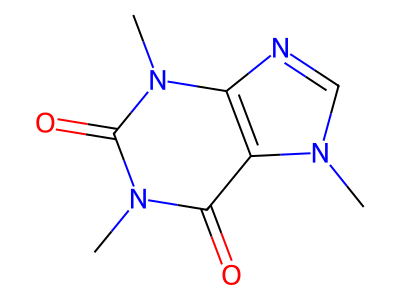

In [3]:
# Create a molecule from SMILES — caffeine, a molecule every chemist knows well.
# Simply placing the mol object as the last expression triggers inline SVG rendering.
caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
caffeine

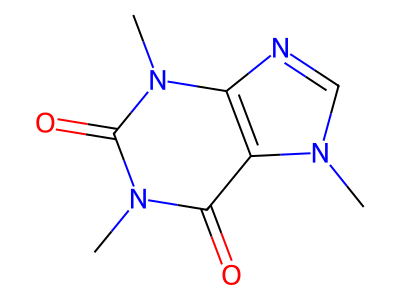

In [4]:
# Compute2DCoords generates a clean 2D layout.
# Without this, RDKit still renders inline, but the coordinates come from the
# SMILES parser's default layout. Calling Compute2DCoords explicitly ensures
# a polished depiction — analogous to "Clean Up Structure" in ChemDraw.
AllChem.Compute2DCoords(caffeine)
caffeine

## 2. Drawing Molecules — Full Control

Inline rendering is convenient for exploration, but for publications, presentations, or reports you need more control: exact dimensions, SVG vs. PNG, atom index labels, custom colors, and highlighting.

RDKit provides two main pathways:
- **`Draw.MolToImage()`** — returns a PIL `Image` object (raster/PNG). Quick and simple.
- **`rdMolDraw2D.MolDraw2DSVG`** — returns scalable SVG text. Better for publications because it stays crisp at any zoom level.

### 2a. PIL Image (raster)

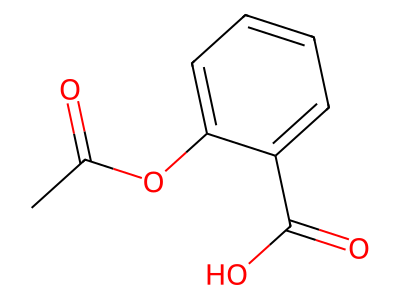

In [5]:
# Draw.MolToImage returns a PIL Image — good for quick exports or embedding in reports.
# You can save it with img.save("caffeine.png").
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
AllChem.Compute2DCoords(aspirin)

img = Draw.MolToImage(aspirin, size=(400, 300))
img

### 2b. SVG rendering (vector — publication quality)

SVG output is resolution-independent, making it ideal for journal figures. The `MolDraw2DSVG` class gives you a canvas you configure before drawing.

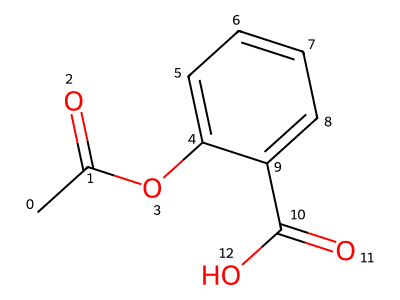

In [6]:
# SVG rendering with atom indices — useful for identifying atoms by index
# when you need to programmatically highlight or modify specific positions.

aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
AllChem.Compute2DCoords(aspirin)

drawer = rdMolDraw2D.MolDraw2DSVG(400, 300)
opts = drawer.drawOptions()
opts.addAtomIndices = True   # label each atom with its index
drawer.DrawMolecule(aspirin)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())

### 2c. Customizing `MolDrawOptions`

`MolDrawOptions` lets you tweak virtually every aspect of the depiction. Think of it as the "Preferences" dialog in ChemDraw — except it is scriptable and reproducible.

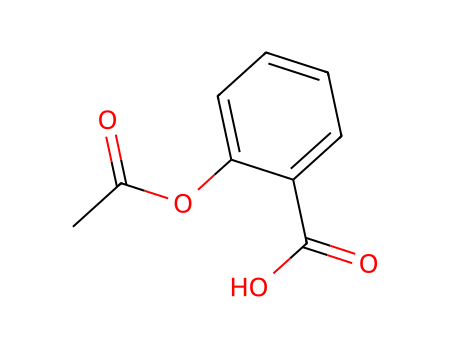

In [9]:
# Customizing drawing options for a polished figure.
drawer = rdMolDraw2D.MolDraw2DSVG(450, 350)
opts = drawer.drawOptions()

# Typography and layout
opts.bondLineWidth = 2.0           # thicker bonds — stands out in presentations
opts.multipleBondOffset = 0.15     # spacing between double/triple bond lines
opts.additionalAtomLabelPadding = 0.1
opts.padding = 0.15                # margin around the molecule

# Atom label styling
opts.addAtomIndices = False
opts.addStereoAnnotation = True    # annotate R/S and E/Z

# Background
opts.clearBackground = True        # white background (set False for transparent)

drawer.DrawMolecule(aspirin)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())

### 2d. Highlighting specific atoms by index

Sometimes you need to draw attention to a particular position — say, the site of metabolism or the electrophilic carbon in a warhead. You can pass `highlightAtoms` to the drawer to color specific atoms.

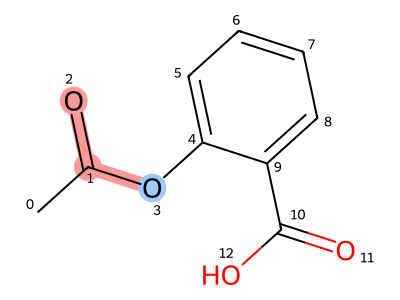

In [10]:
# Highlight the ester oxygen and carbonyl in aspirin (atoms 2, 3 — the acetyl C=O and ester O).
# This is the bond that gets hydrolyzed to release salicylic acid and acetic acid.
# (Run the atom-index cell above to verify which indices correspond to which atoms.)

drawer = rdMolDraw2D.MolDraw2DSVG(400, 300)
opts = drawer.drawOptions()
opts.addAtomIndices = True

# highlightAtoms takes a list of atom indices to color
# highlightAtomColors maps index -> (R, G, B) tuple for custom colors
highlight_atoms = [1, 2, 3]  # the acetyl group C(=O)O
highlight_colors = {
    1: (1.0, 0.6, 0.6),  # light red for the carbonyl carbon
    2: (1.0, 0.6, 0.6),  # light red for the carbonyl oxygen
    3: (0.6, 0.8, 1.0),  # light blue for the ester oxygen
}

drawer.DrawMolecule(
    aspirin,
    highlightAtoms=highlight_atoms,
    highlightAtomColors=highlight_colors,
)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())

## 3. Grid Images — SAR Tables in Code

### Chemistry refresher: Structure-Activity Relationships (SAR)

In medicinal chemistry, **SAR tables** are the workhorse of lead optimization. You line up a series of analogs side by side — usually sharing a common scaffold but varying one substituent at a time — and correlate structural changes with changes in potency, selectivity, or ADMET properties.

On paper, this means printing structures in a grid. Computationally, `Draw.MolsToGridImage` does exactly that. It takes a list of molecules, arranges them in rows, and optionally adds legend text below each structure.

Below we compare six common analgesics/anti-inflammatory drugs — all NSAIDs or related compounds. Notice the shared carboxylic acid motif across most of them (we will highlight that in Section 4).

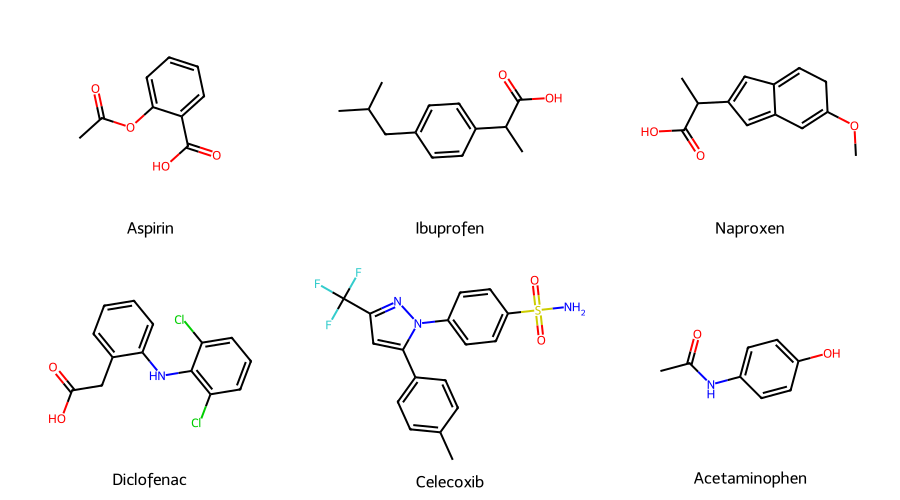

In [11]:
# A small SAR-style panel of analgesics / anti-inflammatory drugs.
smiles_data = {
    "Aspirin":       "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen":     "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Naproxen":      "COC1=CC2=CC(=CC2=CC1)C(C)C(=O)O",
    "Diclofenac":    "OC(=O)CC1=CC=CC=C1NC1=C(Cl)C=CC=C1Cl",
    "Celecoxib":     "CC1=CC=C(C=C1)C1=CC(=NN1C1=CC=C(C=C1)S(N)(=O)=O)C(F)(F)F",
    "Acetaminophen": "CC(=O)NC1=CC=C(O)C=C1",
}

mols = []
names = []
for name, smi in smiles_data.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        AllChem.Compute2DCoords(mol)
        mols.append(mol)
        names.append(name)

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=names,
)
img

**What to notice in the grid above:**

- **Aspirin, Ibuprofen, Naproxen, and Diclofenac** all contain a carboxylic acid group (`-COOH`). This is the classic NSAID pharmacophore — the acid interacts with the Arg-120 residue in the COX active site.
- **Celecoxib** is a COX-2 selective inhibitor (a "coxib"). Instead of a carboxylic acid, it uses a sulfonamide group — a fundamentally different binding mode.
- **Acetaminophen** (paracetamol) is mechanistically distinct from the NSAIDs; its phenol and amide groups are key to its activity.

This kind of visual comparison is exactly what SAR tables are for: spotting shared motifs and structural divergences at a glance.

## 4. Highlighting Substructures

### Chemistry refresher: Pharmacophore highlighting

A **pharmacophore** is the set of molecular features (hydrogen bond donors/acceptors, hydrophobic regions, charged groups) that are essential for biological activity. When analyzing a compound series, one of the first things you do is identify the common pharmacophoric elements.

In RDKit, **substructure matching** with SMARTS lets you find these motifs programmatically. Combined with the drawing engine's highlighting capabilities, you can color-code exactly which atoms belong to the pharmacophore — turning a mental exercise into an automated, reproducible visualization.

Below, we search for the carboxylic acid group (`[CX3](=O)[OX2H1]`) across our NSAID panel. Molecules that contain the motif will have it highlighted; those that do not (celecoxib, acetaminophen) will appear without highlights.

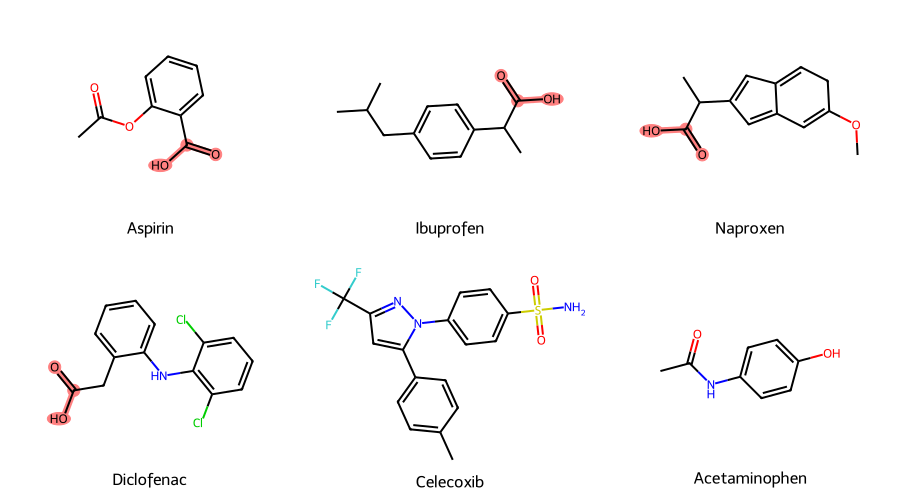

In [12]:
# Highlight carboxylic acid group across the NSAID panel.
# SMARTS pattern: [CX3](=O)[OX2H1] matches a sp2 carbon with =O and -OH.
pattern = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

mols_with_match = []
highlight_atoms = []
for mol in mols:
    match = mol.GetSubstructMatch(pattern)
    mols_with_match.append(mol)
    highlight_atoms.append(list(match))  # empty list if no match — no highlight

img = Draw.MolsToGridImage(
    mols_with_match,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=names,
    highlightAtomLists=highlight_atoms,
)
img

### 4a. Custom-colored substructure highlighting with bond highlighting

The default highlight color is fine for quick checks, but for figures you often want to control colors precisely — for example, using your lab's or journal's color scheme. You can also highlight **bonds** between matched atoms, not just the atoms themselves.

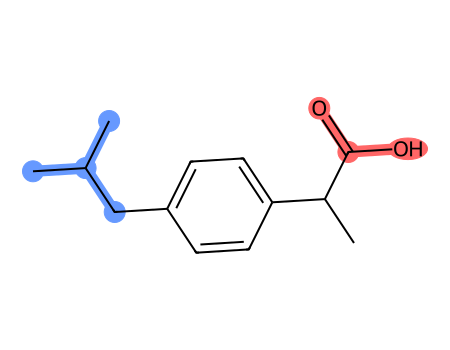

In [13]:
# Custom color highlighting on a single molecule (ibuprofen).
# We will highlight the carboxylic acid in red/orange and the isobutyl group in blue.

ibuprofen = Chem.MolFromSmiles("CC(C)CC1=CC=C(C=C1)C(C)C(=O)O")
AllChem.Compute2DCoords(ibuprofen)

# Find carboxylic acid atoms
acid_pattern = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")
acid_match = ibuprofen.GetSubstructMatch(acid_pattern)

# Find isobutyl group: CC(C)C attached to ring
isobutyl_pattern = Chem.MolFromSmarts("[CH3][CH]([CH3])[CH2]")
isobutyl_match = ibuprofen.GetSubstructMatch(isobutyl_pattern)

# Build color maps: atom index -> (R, G, B)
highlight_atom_list = list(acid_match) + list(isobutyl_match)
highlight_atom_colors = {}
for idx in acid_match:
    highlight_atom_colors[idx] = (1.0, 0.4, 0.4)    # red for acid
for idx in isobutyl_match:
    highlight_atom_colors[idx] = (0.4, 0.6, 1.0)    # blue for isobutyl

# Build bond highlight: find bonds where BOTH atoms are in the same group
highlight_bonds = []
highlight_bond_colors = {}
for bond in ibuprofen.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()
    if a1 in acid_match and a2 in acid_match:
        highlight_bonds.append(bond.GetIdx())
        highlight_bond_colors[bond.GetIdx()] = (1.0, 0.4, 0.4)
    elif a1 in isobutyl_match and a2 in isobutyl_match:
        highlight_bonds.append(bond.GetIdx())
        highlight_bond_colors[bond.GetIdx()] = (0.4, 0.6, 1.0)

drawer = rdMolDraw2D.MolDraw2DSVG(450, 350)
drawer.DrawMolecule(
    ibuprofen,
    highlightAtoms=highlight_atom_list,
    highlightAtomColors=highlight_atom_colors,
    highlightBonds=highlight_bonds,
    highlightBondColors=highlight_bond_colors,
)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())

## 5. Looking Ahead

Visualization goes far beyond 2D depictions. Two important topics that build on this notebook are covered later in the series:

- **Notebook 05 — Fingerprint bit visualization**: See which structural fragments activate specific bits in Morgan/ECFP fingerprints. This connects molecular drawings to the feature vectors used in machine learning.
- **Notebook 06 — Reaction visualization**: Draw chemical reactions (arrow notation) using RDKit's reaction SMARTS and `ReactionToImage`.

## 6. Summary

This notebook covered the core molecular visualization toolkit in RDKit:

| Task | Function / Class | Output |
|---|---|---|
| Quick inline display | `mol` (last expression in cell) | SVG via `_repr_svg_()` |
| Configure inline defaults | `IPythonConsole.molSize`, `.drawOptions` | N/A (side effect) |
| Clean 2D layout | `AllChem.Compute2DCoords(mol)` | Modifies mol in place |
| Raster image (PNG) | `Draw.MolToImage(mol, size=(...))` | PIL `Image` |
| Vector image (SVG) | `rdMolDraw2D.MolDraw2DSVG(w, h)` | SVG string |
| Style control | `drawer.drawOptions()` | `MolDrawOptions` object |
| Grid of molecules | `Draw.MolsToGridImage(mols, ...)` | PIL `Image` |
| Substructure match | `mol.GetSubstructMatch(pattern)` | Tuple of atom indices |
| Atom/bond highlighting | `drawer.DrawMolecule(..., highlightAtoms=...)` | Colored depiction |

**Key takeaway**: RDKit's drawing engine is fully scriptable. Anything you would do interactively in ChemDraw — adjusting bond widths, coloring atoms, annotating stereocenters — can be done in code, making your figures reproducible and automatable.

---

**Next up**: [Notebook 03](./03-molecular-descriptors.ipynb) — Molecular Descriptors: computing physicochemical properties (MW, LogP, TPSA, etc.) and understanding Lipinski's Rule of Five from a cheminformatics perspective.